In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

: 

In [ ]:
test_info_dict_name = f"./data/tmp/test_info_by_hashes.pkl"
with open(test_info_dict_name, "wb") as f:
    pickle.dump(test_info_dict, f)

In [ ]:
import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

: 

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.007776134647428989, slope = 0


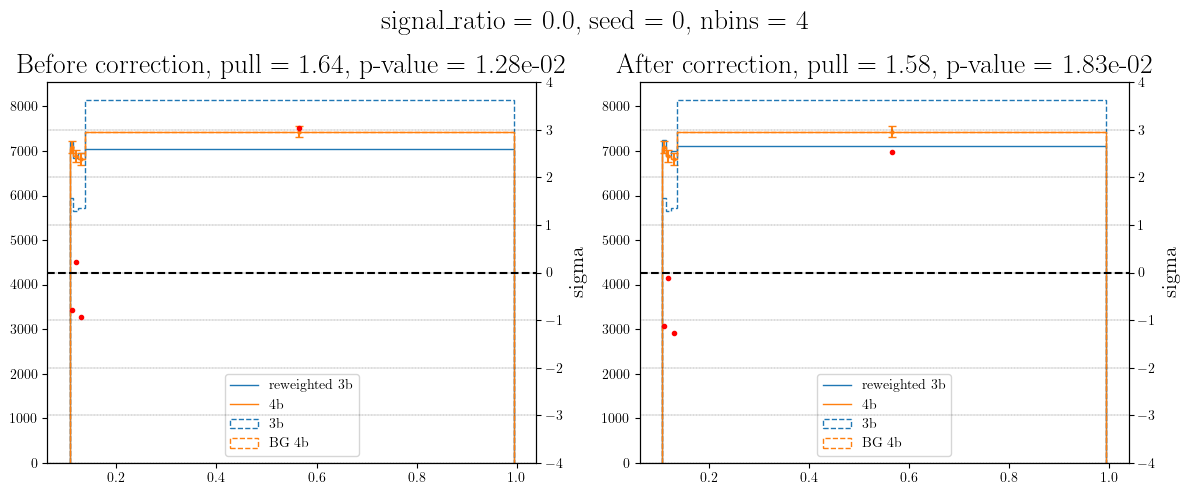

 10%|█         | 1/10 [00:08<01:17,  8.56s/it]

intercept = 0.012738998048007488, slope = 0


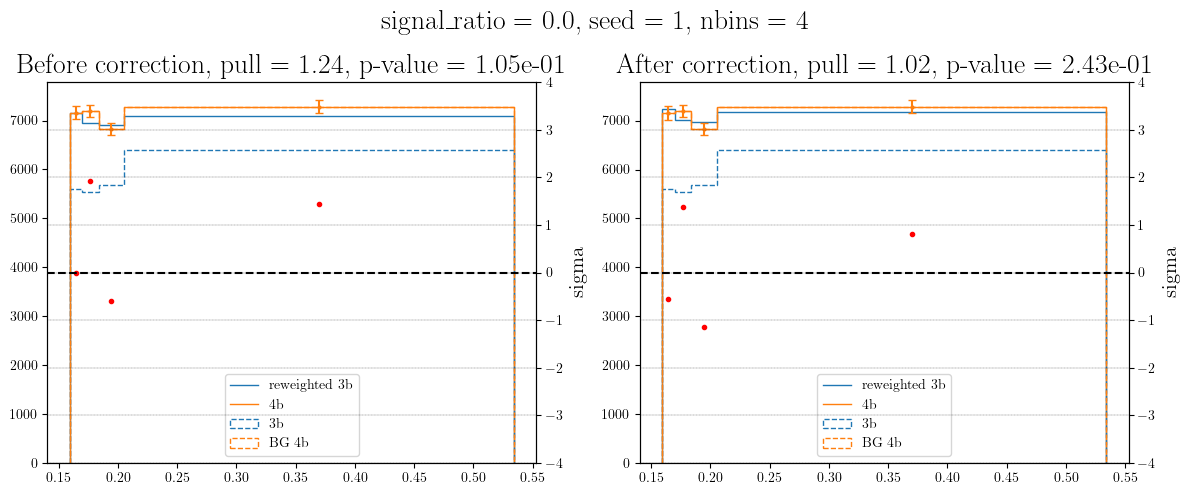

 20%|██        | 2/10 [00:16<01:07,  8.43s/it]

intercept = 0.0026696494314819574, slope = 0


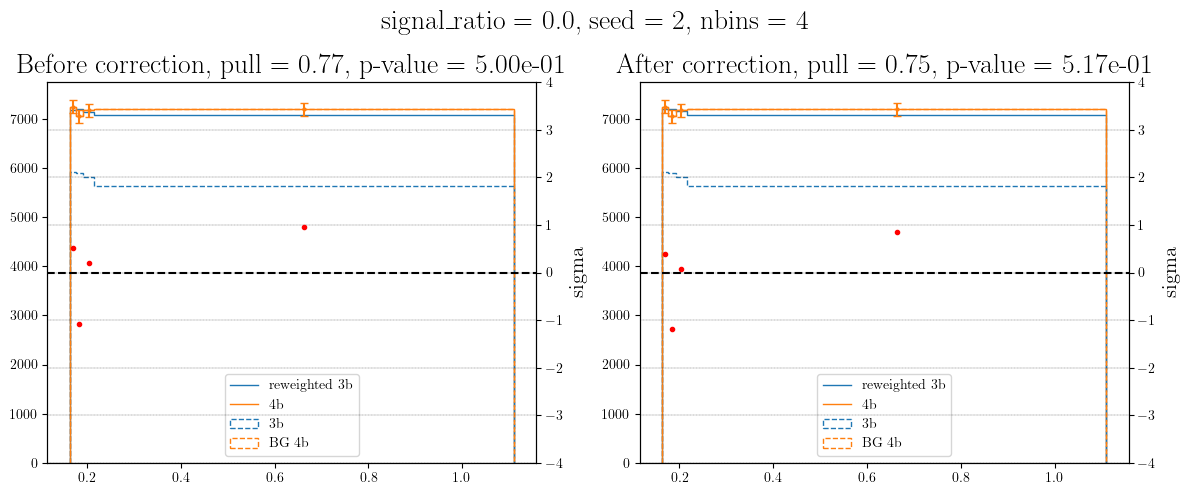

 30%|███       | 3/10 [00:25<00:59,  8.52s/it]

intercept = 0.02534659020602703, slope = 0


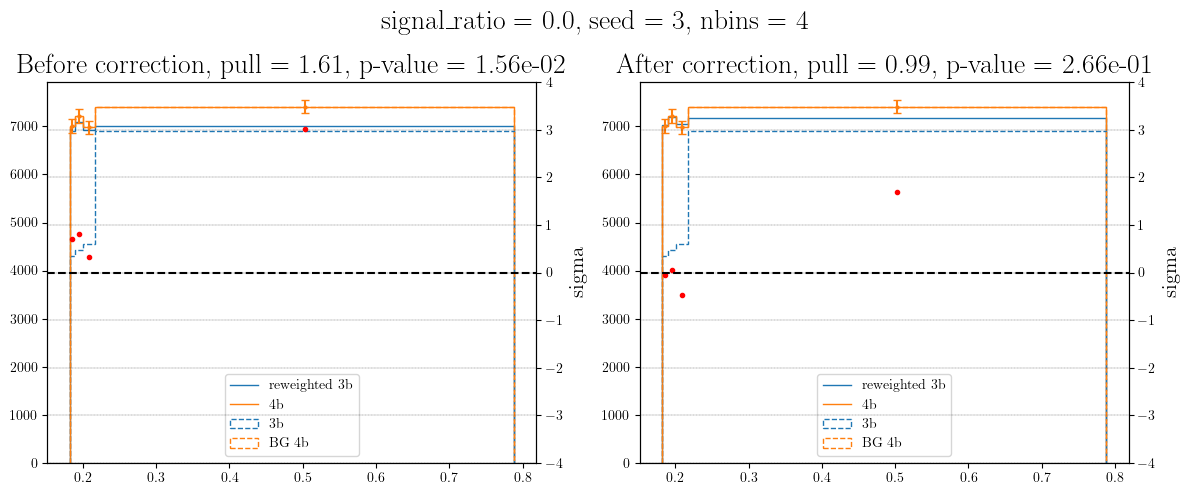

 40%|████      | 4/10 [00:33<00:50,  8.47s/it]

intercept = 0.03926662355661392, slope = 0


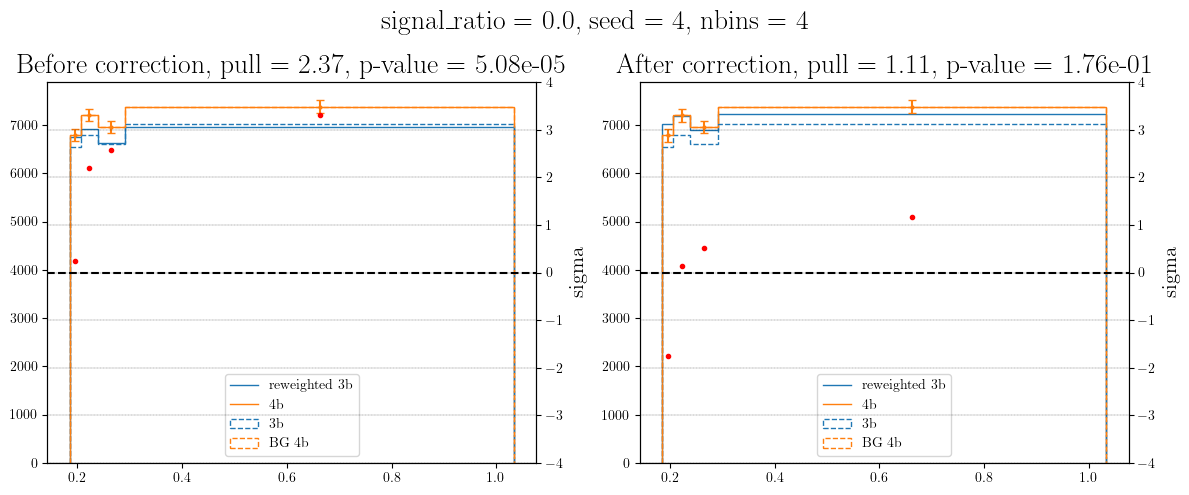

 50%|█████     | 5/10 [00:42<00:41,  8.38s/it]

intercept = 0.014571532607078552, slope = 0


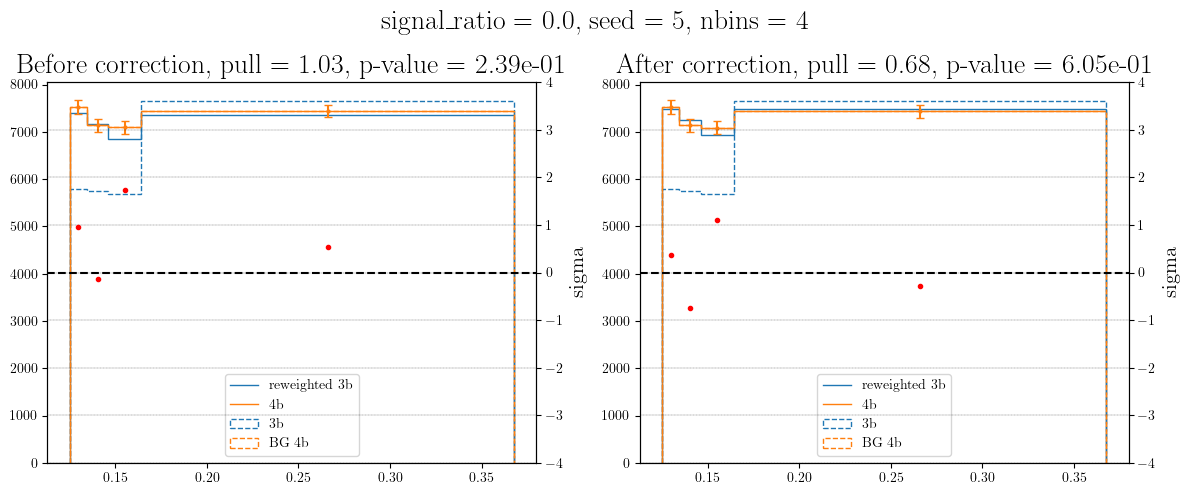

 60%|██████    | 6/10 [00:50<00:33,  8.32s/it]

intercept = 0.027234498411417007, slope = 0


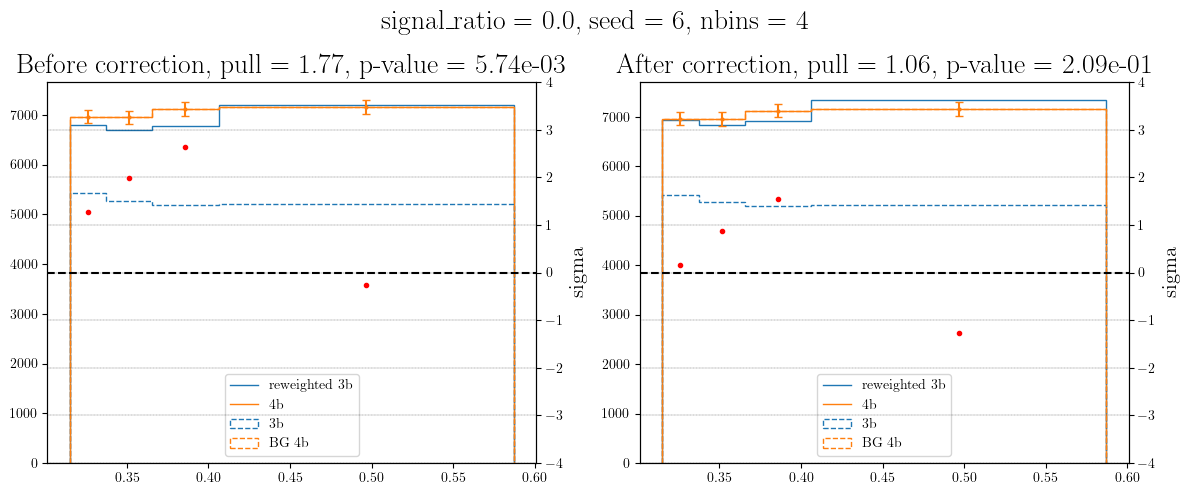

 70%|███████   | 7/10 [00:58<00:24,  8.31s/it]

intercept = -0.03502096235752106, slope = 0


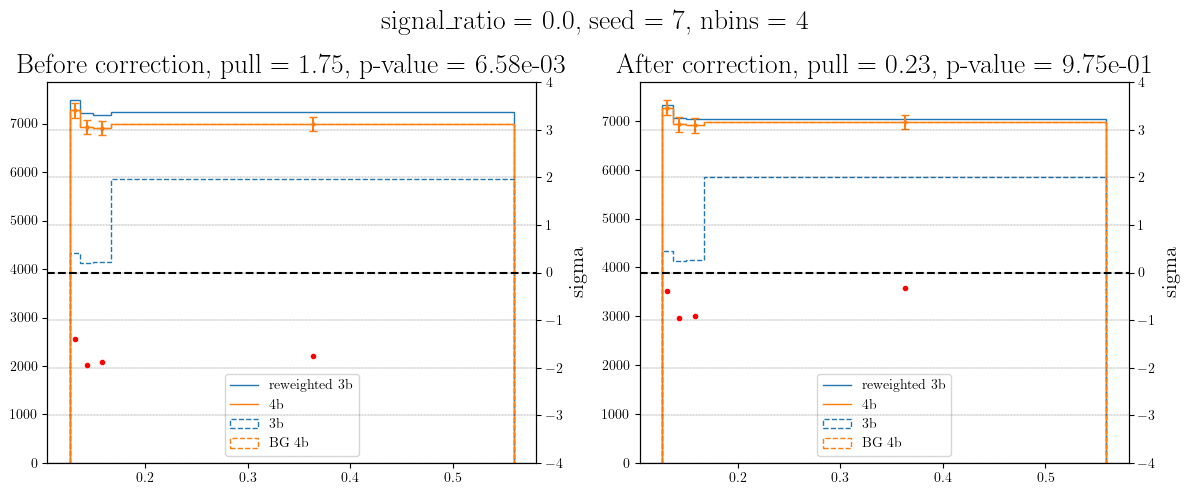

 80%|████████  | 8/10 [01:06<00:16,  8.26s/it]

intercept = -0.011031066998839378, slope = 0


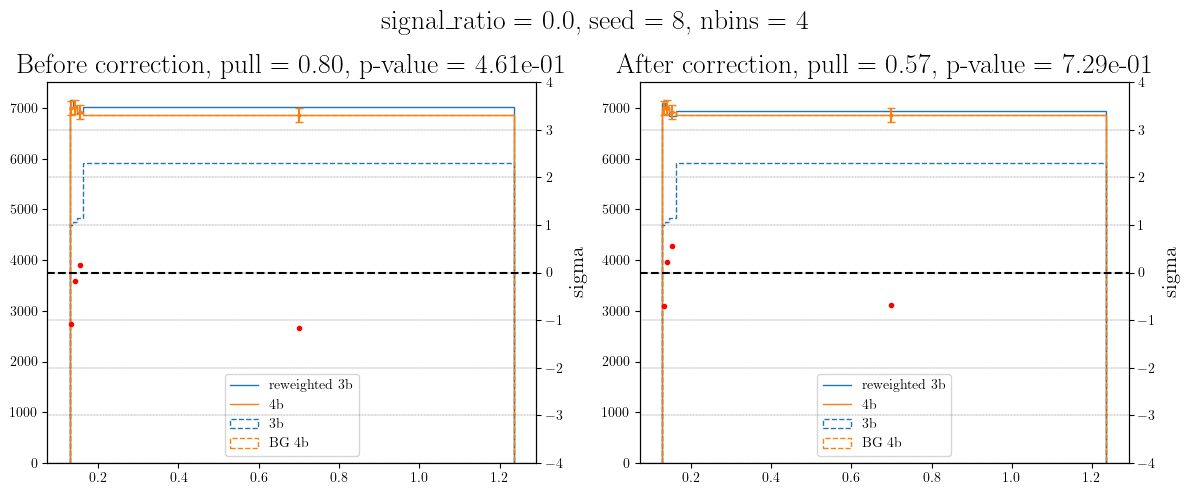

 90%|█████████ | 9/10 [01:14<00:08,  8.17s/it]

intercept = 0.016799237579107285, slope = 0


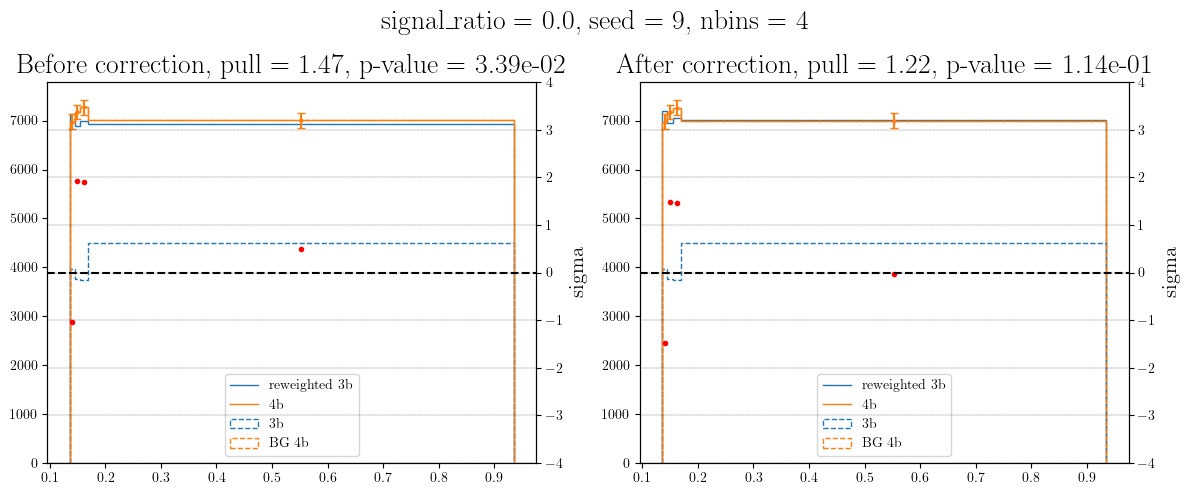

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.022735867649316788, slope = 0


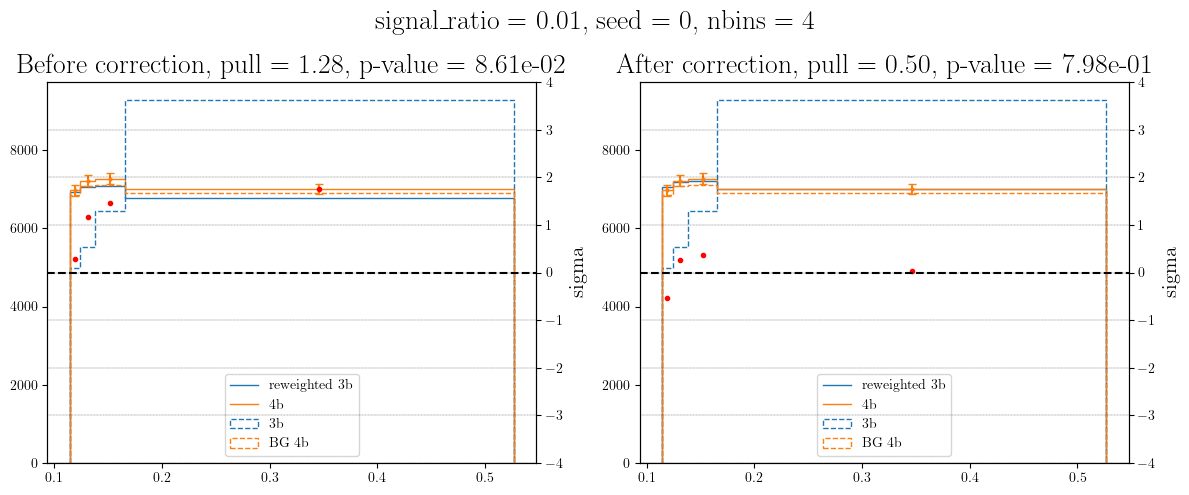

 10%|█         | 1/10 [00:08<01:13,  8.13s/it]

intercept = 0.014568908140063286, slope = 0


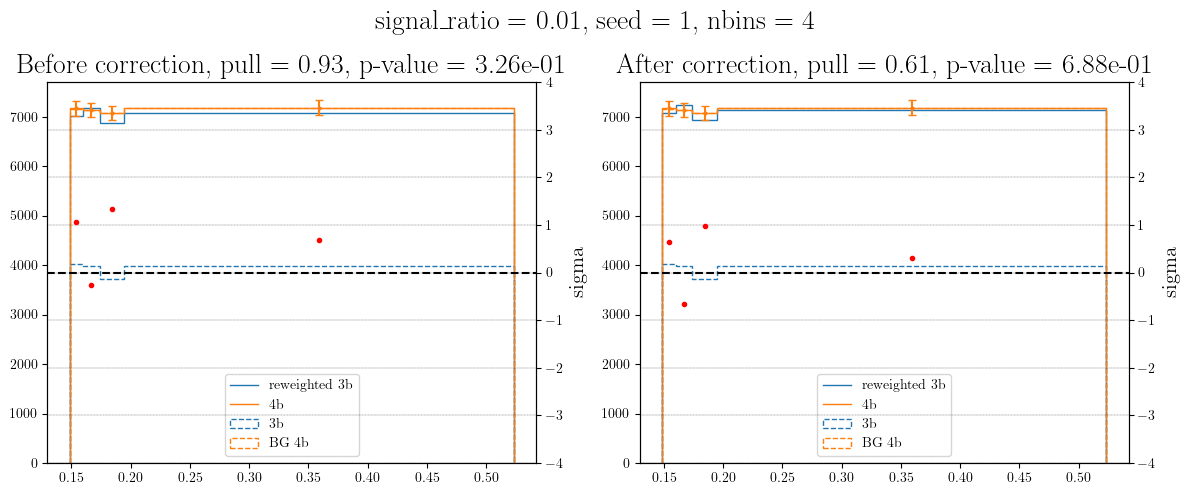

 20%|██        | 2/10 [00:16<01:04,  8.08s/it]

intercept = -0.014143739826977253, slope = 0


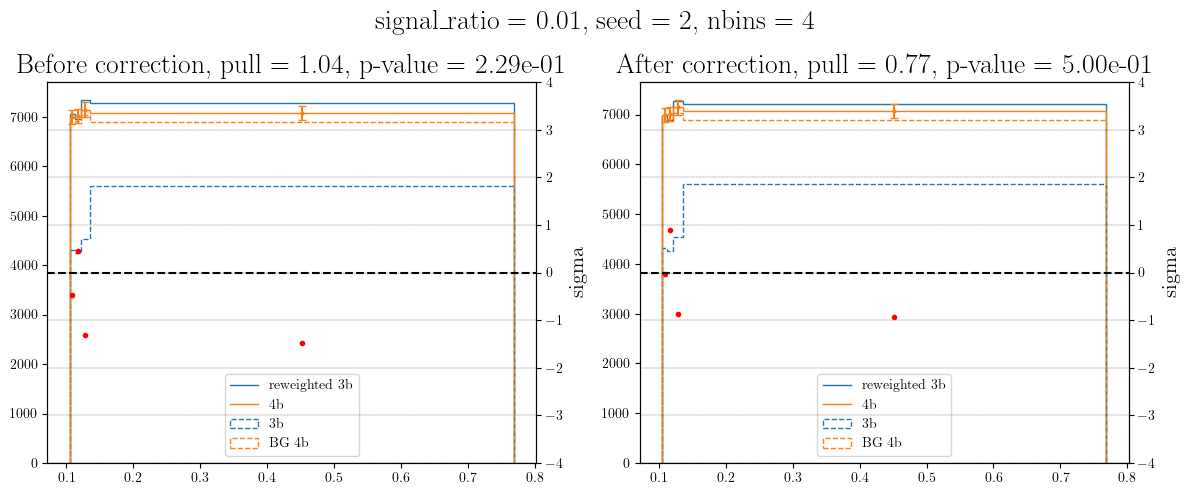

 30%|███       | 3/10 [00:24<00:56,  8.01s/it]

intercept = 0.1268949806690216, slope = 0


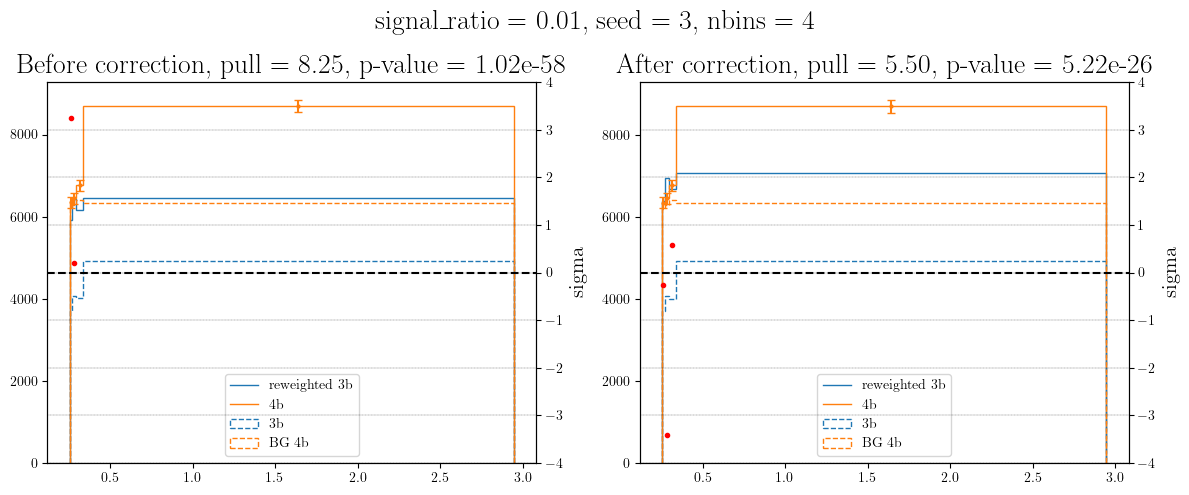

 40%|████      | 4/10 [00:31<00:47,  7.93s/it]

intercept = 0.09823828190565109, slope = 0


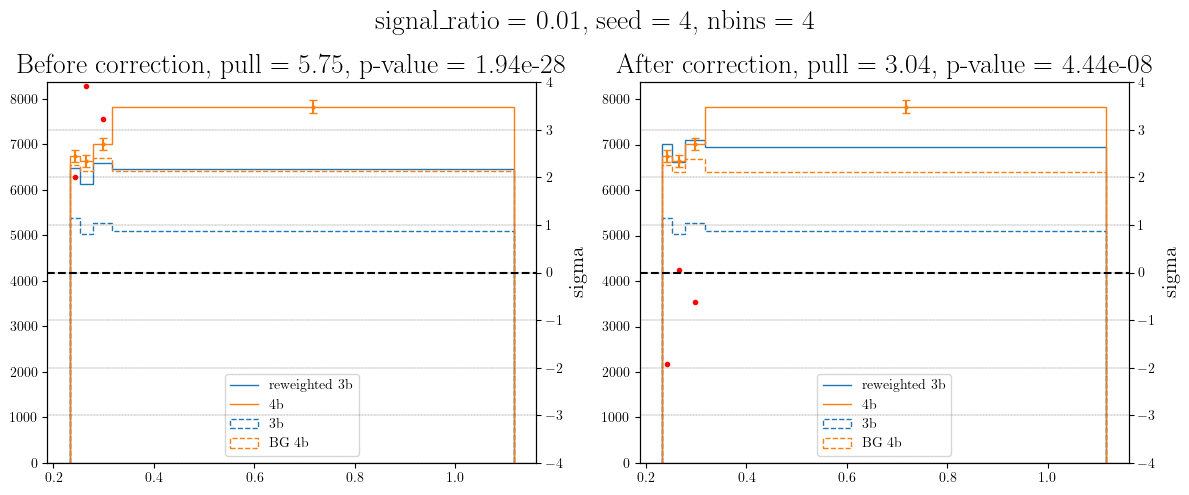

 50%|█████     | 5/10 [00:39<00:39,  7.94s/it]

intercept = 0.12420019507408142, slope = 0


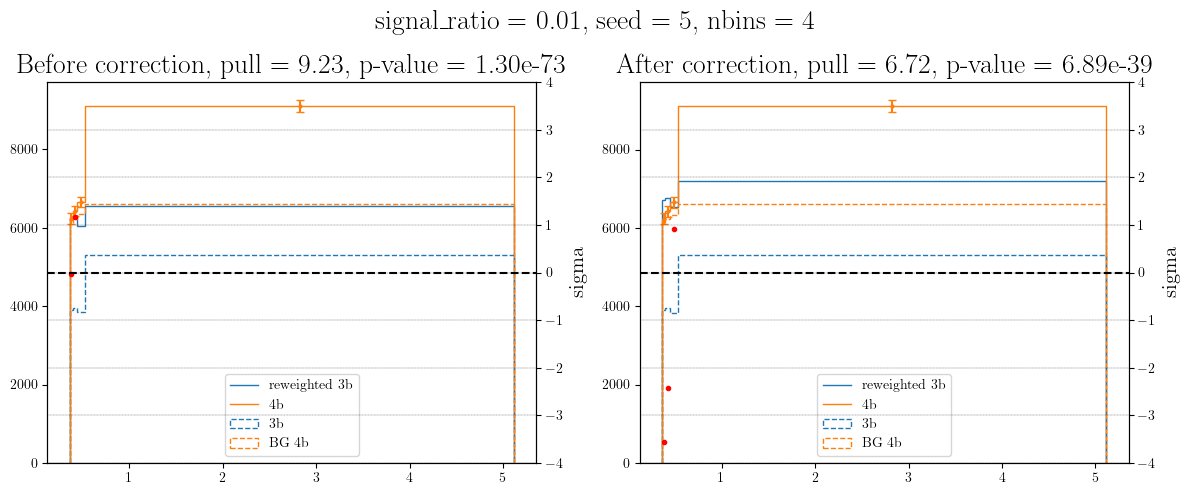

 60%|██████    | 6/10 [00:47<00:31,  7.92s/it]

intercept = 0.0888173058629036, slope = 0


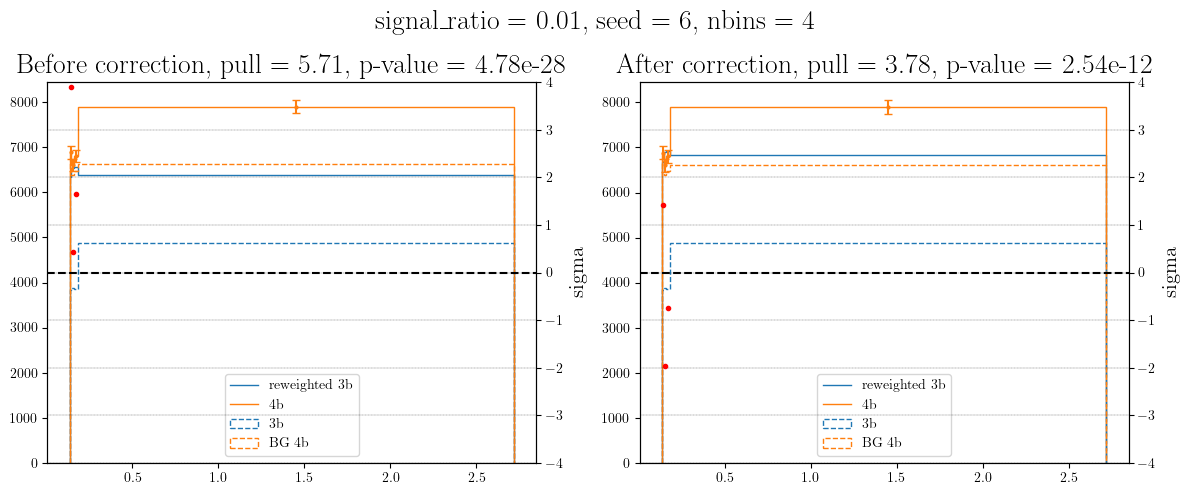

 70%|███████   | 7/10 [00:55<00:23,  7.89s/it]

intercept = 0.0013544757384806871, slope = 0


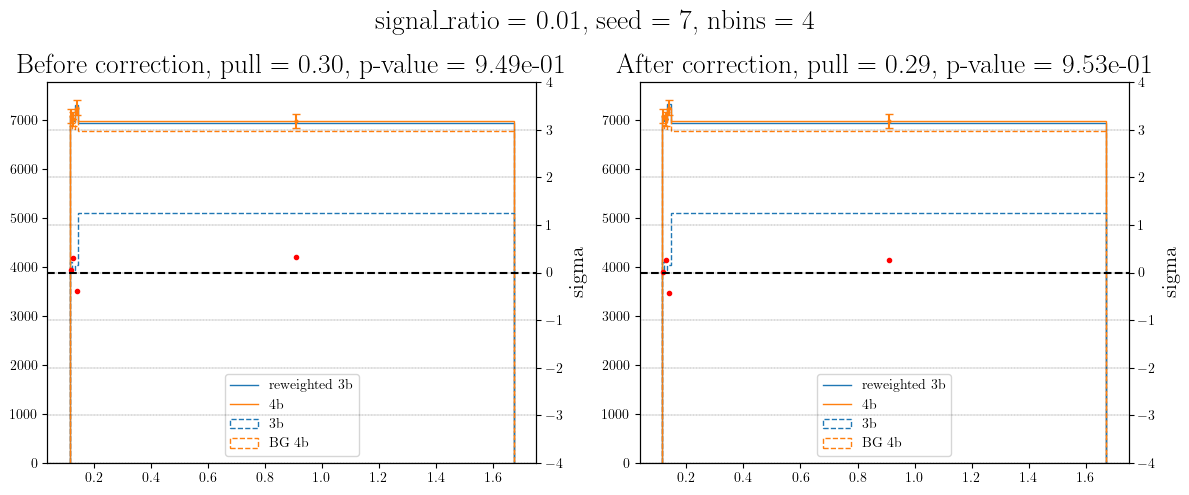

 80%|████████  | 8/10 [01:03<00:15,  7.79s/it]

intercept = 0.04710884764790535, slope = 0


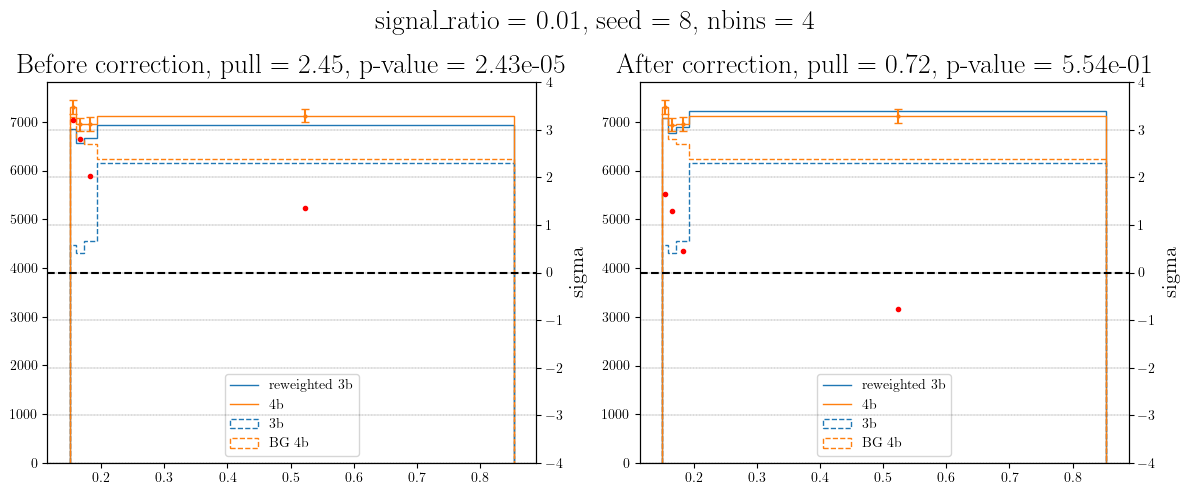

 90%|█████████ | 9/10 [01:10<00:07,  7.73s/it]

intercept = -0.017835110425949097, slope = 0


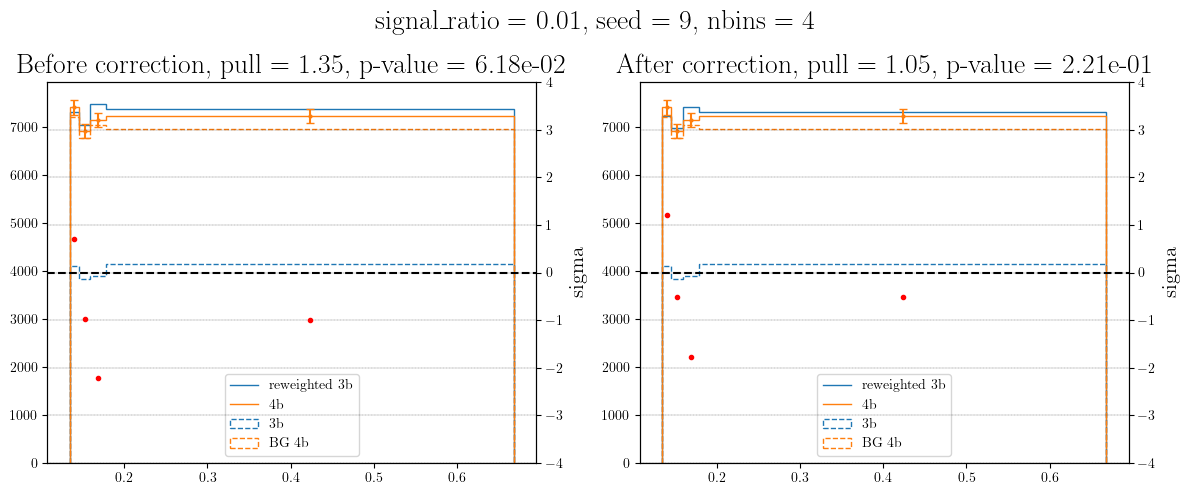

  0%|          | 0/10 [00:00<?, ?it/s]

intercept = 0.29876771569252014, slope = 0


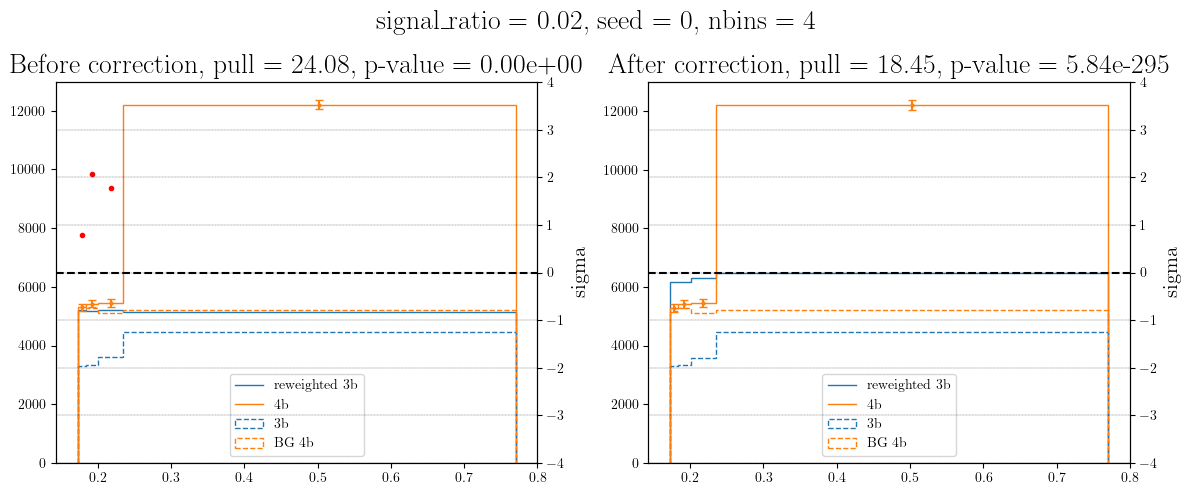

 10%|█         | 1/10 [00:08<01:13,  8.14s/it]

intercept = 0.2448212057352066, slope = 0


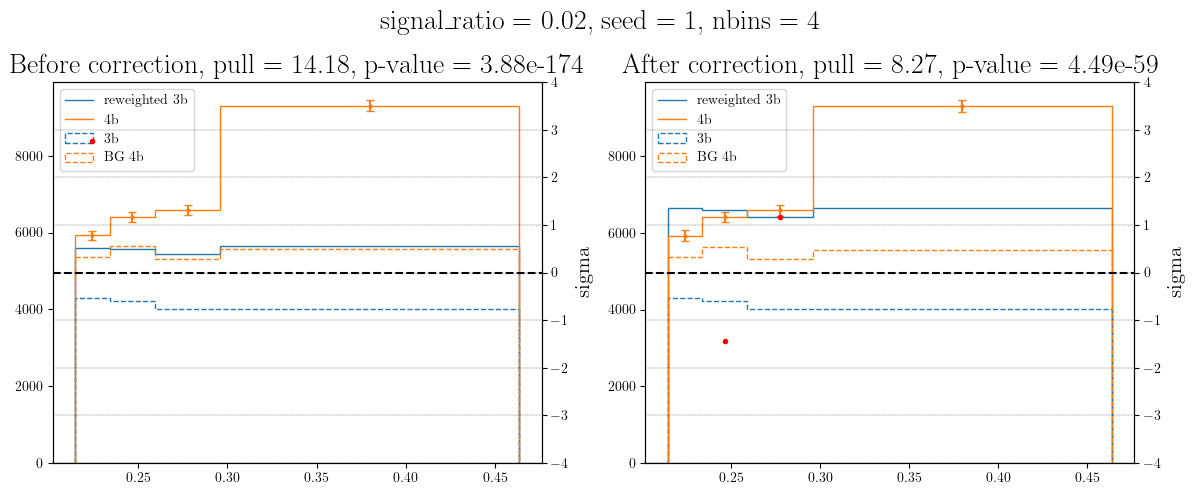

 20%|██        | 2/10 [00:16<01:07,  8.43s/it]

intercept = 0.34041205048561096, slope = 0


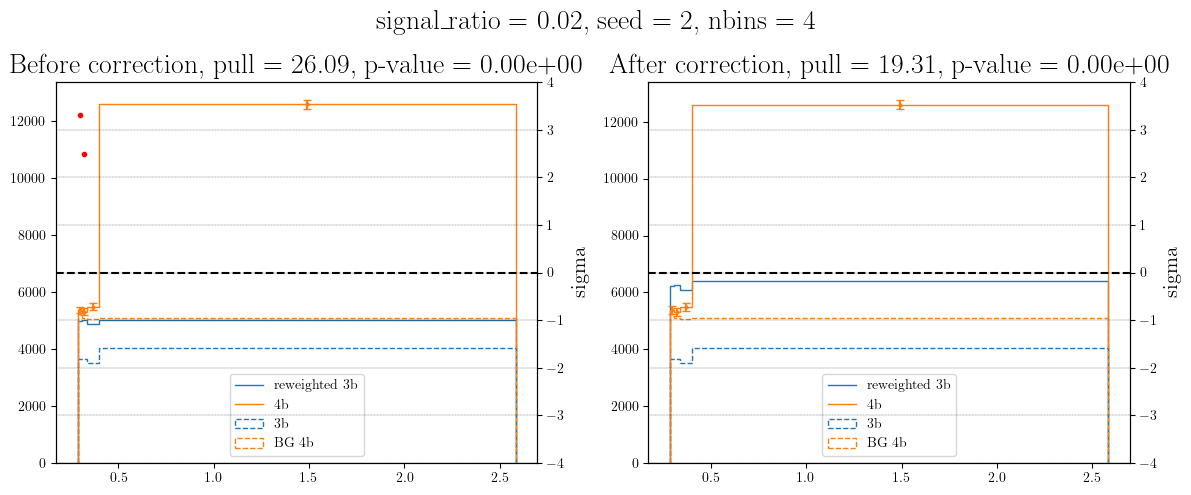

 30%|███       | 3/10 [00:25<00:59,  8.47s/it]

intercept = 0.37215718626976013, slope = 0


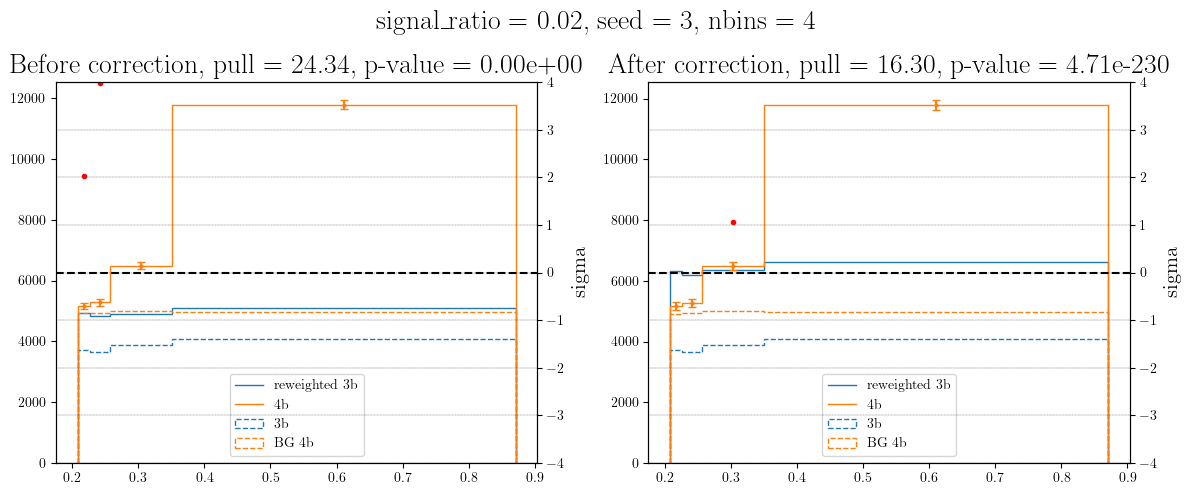

 40%|████      | 4/10 [00:33<00:51,  8.54s/it]

intercept = 0.1730618178844452, slope = 0


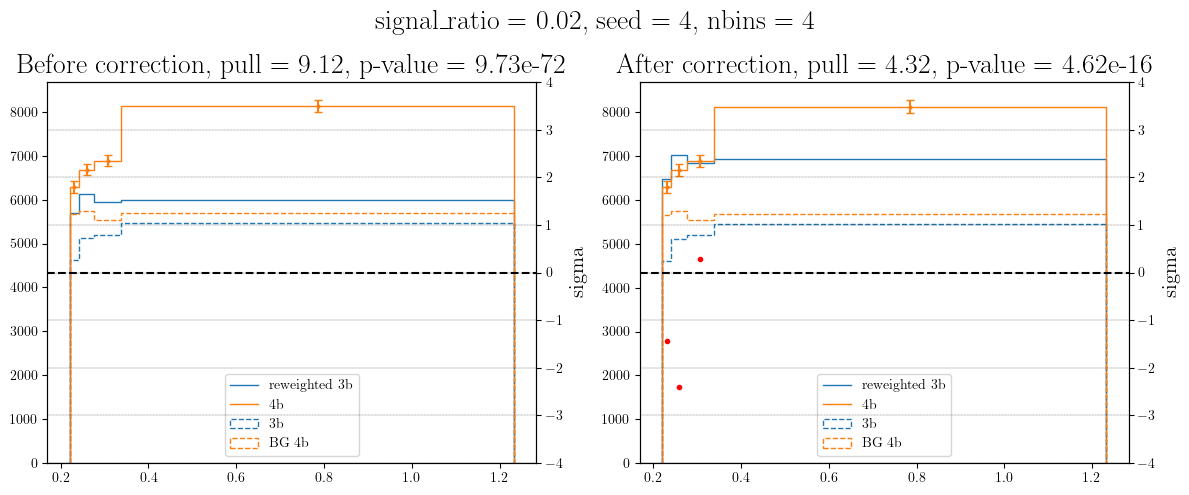

 50%|█████     | 5/10 [00:43<00:44,  8.85s/it]

intercept = -0.004412227310240269, slope = 0


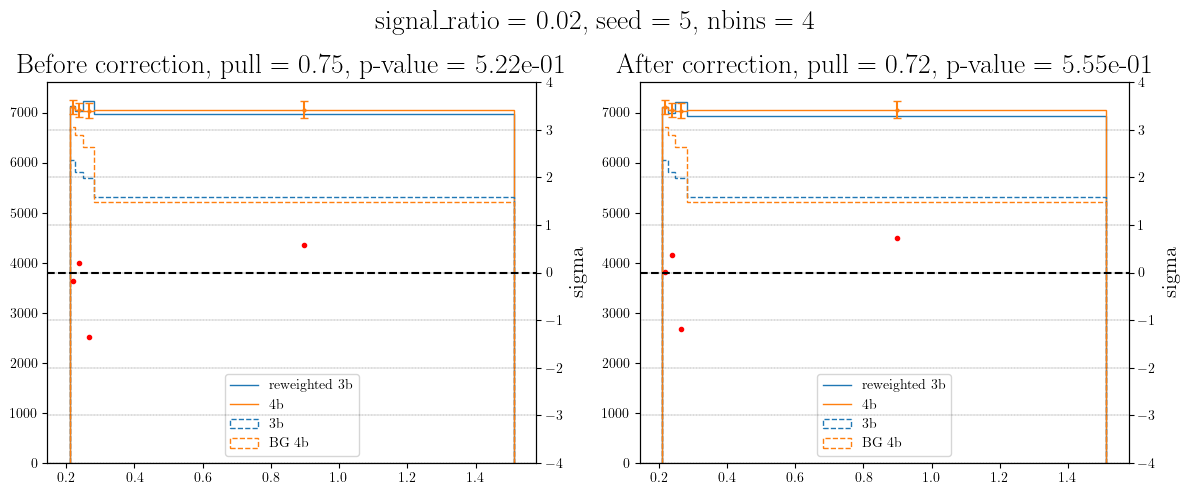

 60%|██████    | 6/10 [00:52<00:35,  8.91s/it]

intercept = 0.2456667274236679, slope = 0


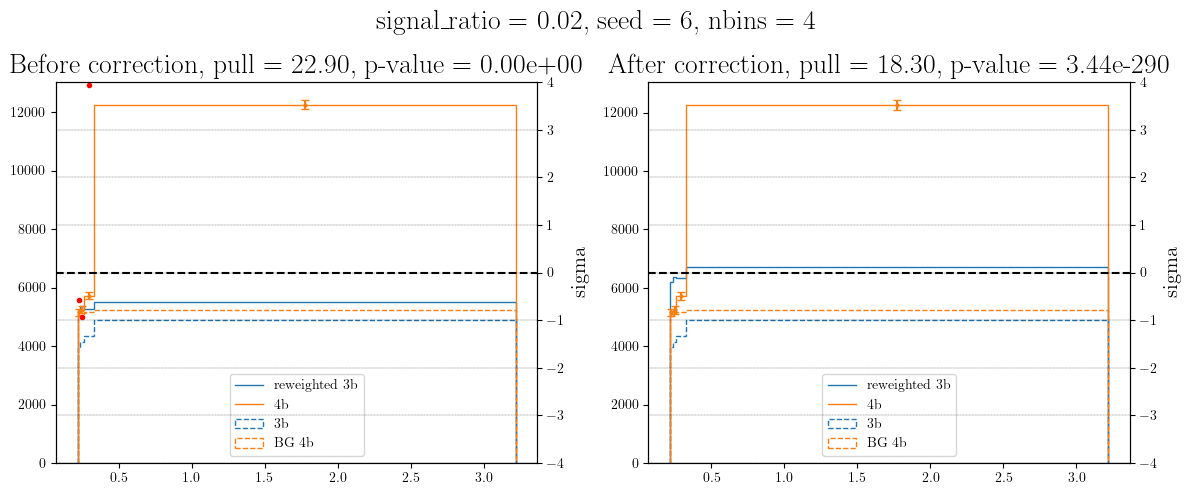

 70%|███████   | 7/10 [01:01<00:27,  9.01s/it]

intercept = 0.251039981842041, slope = 0


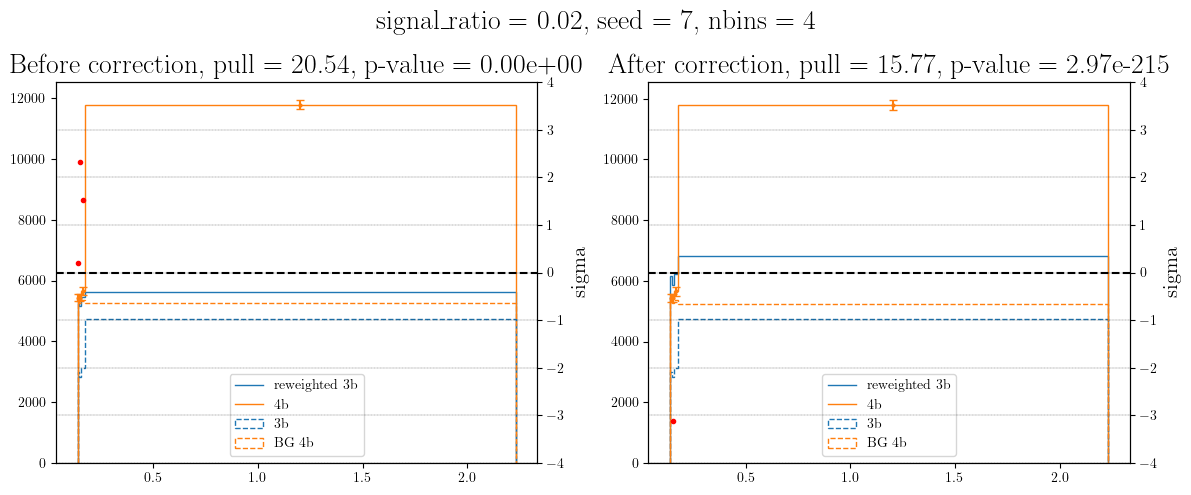

 80%|████████  | 8/10 [01:10<00:17,  8.85s/it]

intercept = 0.004110594280064106, slope = 0


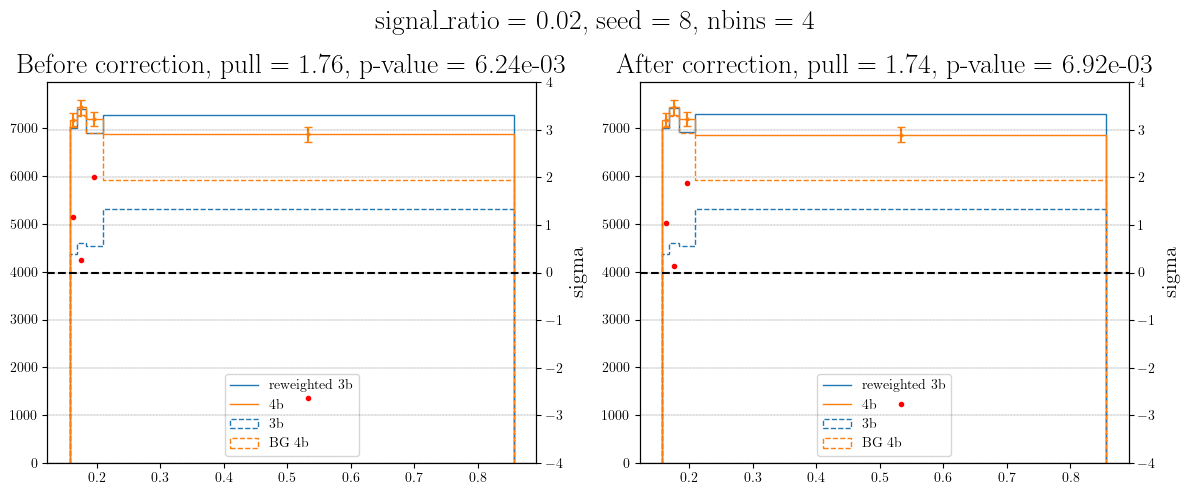

 90%|█████████ | 9/10 [01:19<00:09,  9.05s/it]

intercept = 0.19665677845478058, slope = 0


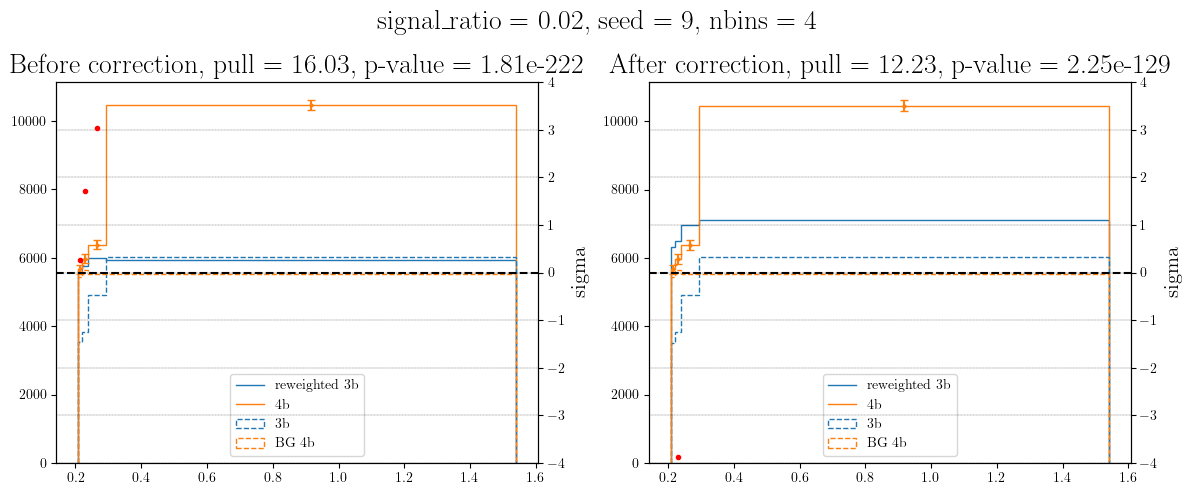

100%|██████████| 10/10 [01:28<00:00,  8.83s/it]


In [6]:
from correct_systematic_error import constrained_linear_fit, get_histograms
from utils import get_quantiles_with_weights
from events_data import get_is_signal
from signal_region import get_SR_CR_cut
from scipy import stats

slope_min = -0.0
slope_max = 0.0
intercept_min = -np.inf
intercept_max = np.inf
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_v2"
n_3b = 100_0000

seeds = np.arange(10)
nbins_list = [2**i for i in range(2, 3)]

for signal_ratio in [0.0, 0.01, 0.02]:
    for seed in tqdm.tqdm(seeds):
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        
        CR_fvt_tinfo = TrainingInfo.load(hashes[0])
        base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

        base_fvt_model = base_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier

        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))
        smeared_fvt_model: AttentionClassifier

        # Use the same mother samples and exclude ones used for training base & smeared FvT model
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
        df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
        events_train = EventsData.from_dataframe(df_train, features)
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)
        SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
        SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

        SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
        
        SR_idx = (SR_stats >= SR_cut)
        CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)
        
        events_train_SR = events_train[(SR_stats_train >= SR_cut)]
        SR_stats_train_SR = SR_stats_train[(SR_stats_train >= SR_cut)]
        
        events_tst_SR = events_tst[SR_idx]
        SR_stats_SR = SR_stats[SR_idx]
        
        CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
        CR_fvt_model.eval()
        CR_fvt_model.to(torch.device("cuda"))
        
        CR_fvt_model: FvTClassifier
        CR_fvt_scores = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()
                
        fvt_scores_SR = CR_fvt_scores[SR_idx]
        reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
        reweights_SR = np.where(events_tst_SR.is_4b, 1, reweights_SR)
        
        fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
        reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
        reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)
        
        for nbins in nbins_list:
            SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
                                                (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
                                                np.linspace(0, 1, nbins + 1))
            
            hists = get_histograms(events_tst_SR, SR_stats_SR, SR_bins, reweights_SR)
            
            y = hists["4b"] - hists["3b_rw"]
            X = np.stack([hists["3b_rw"], hists["3b_x"]], axis=1)
            V = np.diag(hists["3b_sq"] + hists["4b_sq"])

            if nbins > 1:
                intercept, slope = constrained_linear_fit(X, y, V,
                                                        beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                        beta_1_min=slope_min, beta_1_max=slope_max)
            else:
                intercept, slope = constrained_linear_fit(X, y, V,
                                                        beta_0_min=intercept_min, beta_0_max=intercept_max,
                                                        beta_1_min=0, beta_1_max=0)
            
            print(f"intercept = {intercept}, slope = {slope}")
            

            # corrected_reweights = (
            #     reweights_SR[~train_idx] + intercept + slope * SR_stats_SR_test
            # )
            corrected_reweights = reweights_SR * (1 + intercept + slope * SR_stats_SR)
            corrected_weights = (
                np.where(events_tst_SR.is_4b, 1, corrected_reweights)
                * events_tst_SR.weights
            )

            hist_3b_corrected = np.histogram(
                SR_stats_SR[events_tst_SR.is_3b],
                bins=SR_bins,
                weights=corrected_weights[events_tst_SR.is_3b],
            )[0]
            hist_3b_corrected_sq = np.histogram(
                SR_stats_SR[events_tst_SR.is_3b],
                bins=SR_bins,
                weights=corrected_weights[events_tst_SR.is_3b] ** 2,
            )[0]
            hists["3b_corrected"] = hist_3b_corrected
            hists["3b_corrected_sq"] = hist_3b_corrected_sq
            
            diff_orig = hists["4b"] - hists["3b_rw"]
            var_orig = hists["3b_sq"] + hists["4b_sq"]
            
            diff_corrected = hists["4b"] - hists["3b_corrected"]
            var_corrected = hists["3b_corrected_sq"] + hists["4b_sq"]

            mean_pull_orig = np.sqrt(np.mean(diff_orig**2 / var_orig))
            mean_pull_corrected = np.sqrt(np.mean(diff_corrected**2 / var_corrected))
            
            deg_freedom = nbins - 1
            chi2_stat_orig = nbins * mean_pull_orig**2
            chi2_stat_corrected = nbins * mean_pull_corrected**2
            p_value_orig = stats.chi2.sf(chi2_stat_orig, deg_freedom)
            p_value_corrected = stats.chi2.sf(chi2_stat_corrected, deg_freedom)

            new_weights = events_tst_SR.weights.copy()
            new_weights[events_tst_SR.is_3b] = new_weights[events_tst_SR.is_3b] * (
                reweights_SR[events_tst_SR.is_3b] + intercept + slope * SR_stats_SR[events_tst_SR.is_3b])

            fig, ax = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f"signal_ratio = {signal_ratio}, seed = {seed}, nbins = {nbins}")
            ax[0].set_title(f"Before correction, pull = {mean_pull_orig:.2f}, p-value = {p_value_orig:.2e}")
            ax[1].set_title(f"After correction, pull = {mean_pull_corrected:.2f}, p-value = {p_value_corrected:.2e}")
            plot_samples_raw(events_tst_SR.is_4b, reweights_SR * events_tst_SR.weights, SR_stats_SR, ax[0], bins=SR_bins)
            ax[0].hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_3b], 
                       histtype="step", label="3b", linestyle="--")
            ax[0].hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b], 
                       histtype="step", label="BG 4b", linestyle="--")
            ax[0].legend()
            plot_samples_raw(events_tst_SR.is_4b, new_weights, SR_stats_SR, ax[1], bins=SR_bins)
            ax[1].hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_3b], 
                       histtype="step", label="3b", linestyle="--")
            ax[1].hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b], 
                       histtype="step", label="BG 4b", linestyle="--")
            ax[1].legend()
            plt.tight_layout()
            plt.show()

In [7]:
import pickle
from correct_systematic_error import correct_systematic_error
from itertools import product

seeds = np.arange(50)
nbins_list = [2**i for i in range(7)]
experiment_name = "CR_fvt_training_v2"
bins_mode = "quantile"
n_3b = 100_0000

corrections_dict = {}
hists_dict = {}

pull_arrays_dict = {}
for slope_min, slope_max, intercept_min, intercept_max in [
    (0.0, 0.0, -np.inf, np.inf),
]:
    print(f"slope_min = {slope_min}, slope_max = {slope_max}, intercept_min = {intercept_min}, intercept_max = {intercept_max}")
    for signal_ratio in [0.0, 0.01, 0.02]:
        for seed in tqdm.tqdm(seeds):
            hparam_filter = {
                "experiment_name": experiment_name,
                "dataset": lambda x: all([x["seed"] == seed, 
                                    x["n_3b"] == n_3b, 
                                    x["signal_ratio"] == signal_ratio]),
                "aux_info_step": 3, 
                "model": "FvTClassifier"
            }
            hashes = TrainingInfo.find(hparam_filter)
            assert len(hashes) == 1
            
            hash = hashes[0]
            corrections, hists = correct_systematic_error(hash, nbins_list, bins_mode, 
                                    intercept_min=intercept_min,
                                    intercept_max=intercept_max,
                                    slope_min=slope_min,
                                    slope_max=slope_max,
                                    raw_df_list=raw_df_list)
            
            corrections_dict[(signal_ratio, seed)] = corrections
            hists_dict[(signal_ratio, seed)] = hists
            
    pull_arrays = {(signal_ratio, nbins): [] for signal_ratio, nbins in product([0.0, 0.01, 0.02], nbins_list)}

    for signal_ratio, seed in tqdm.tqdm(product([0.0, 0.01, 0.02], seeds)):
        for nbins in nbins_list:
            hist_3b_corrected = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected"]
            hist_3b_corrected_sq = hists_dict[(signal_ratio, seed)][nbins]["3b_corrected_sq"]
            hist_4b = hists_dict[(signal_ratio, seed)][nbins]["4b"]
            hist_4b_sq = hists_dict[(signal_ratio, seed)][nbins]["4b_sq"]
            hist_diff = hist_4b - hist_3b_corrected
            hist_var = hist_3b_corrected_sq + hist_4b_sq
            pull = hist_diff / np.sqrt(hist_var)
            pull_arrays[(signal_ratio, nbins)].append(pull)
            
    pull_arrays = {k: np.array(v) for k, v in pull_arrays.items()}
    pull_arrays_dict[(slope_min, slope_max, intercept_min, intercept_max)] = pull_arrays

with open("./data/tmp/pull_arrays_dict.pkl", "wb") as f:
    pickle.dump(pull_arrays_dict, f)

slope_min = 0.0, slope_max = 0.0, intercept_min = -inf, intercept_max = inf


100%|██████████| 50/50 [02:39<00:00,  3.18s/it]
150it [00:00, 21466.68it/s]


In [9]:
from signal_region import get_SR_CR_cut
from events_data import get_is_signal

seeds = np.arange(50)
nbins_list = [2**i for i in range(7)]
experiment_name = "CR_fvt_training_v2"
bins_mode = "quantile"
n_3b = 100_0000
signal_filename = "HH4b_picoAOD.h5"

signal_ratio_in_SR = {signal_ratio: [] for signal_ratio in [0.0, 0.01, 0.02]}
for signal_ratio in [0.0, 0.01, 0.02]:
    for seed in tqdm.tqdm(seeds):
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        
        hash = hashes[0]
        CR_fvt_tinfo = TrainingInfo.load(hash)
        smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)

        train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
        df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
        events_train = EventsData.from_dataframe(df_train, features)

        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
        SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
        SR_cut, _ = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
        SR_idx = SR_stats_tst >= SR_cut
        scdinfo_SR = tst_scdinfo[SR_idx]
        events_SR = EventsData.from_dataframe(
            scdinfo_SR.fetch_data_with_loaded_df(raw_df_list), features
        )
        signal_ratio_in_SR[signal_ratio].append(events_SR.total_weight_signal / events_SR.total_weight_4b)
        
signal_ratio_in_SR = {signal_ratio: np.array(v) for signal_ratio, v in signal_ratio_in_SR.items()}

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:36<00:00,  1.94s/it]


In [5]:
import pickle
pull_arrays_dict = pickle.load(open("./data/tmp/pull_arrays_dict.pkl", "rb"))

In [6]:
from itertools import product
from scipy import stats

sig_level = 0.05
nbins_list = [2**i for i in range(1, 7)]

for (slope_min, slope_max, intercept_min, intercept_max), pull_arrays in pull_arrays_dict.items():
    print(f"slope_min = {slope_min}, slope_max = {slope_max}, intercept_min = {intercept_min}, intercept_max = {intercept_max}")
    for nbins, signal_ratio in product(nbins_list, [0.0, 0.01, 0.02]):
        print(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
        chi2_stat = np.sqrt(np.mean(pull_arrays[(signal_ratio, nbins)]**2, axis=1))
        z_rej = stats.chi2.ppf(1 - sig_level, df=nbins-1)
        z_rej = np.sqrt(z_rej / nbins)
        print(np.mean(chi2_stat > z_rej))

slope_min = 0.0, slope_max = 0.0, intercept_min = -inf, intercept_max = inf
signal_ratio = 0.0, nbins = 2
0.06
signal_ratio = 0.01, nbins = 2
0.5
signal_ratio = 0.02, nbins = 2
0.48
signal_ratio = 0.0, nbins = 4
0.08
signal_ratio = 0.01, nbins = 4
0.5
signal_ratio = 0.02, nbins = 4
0.5
signal_ratio = 0.0, nbins = 8
0.08
signal_ratio = 0.01, nbins = 8
0.52
signal_ratio = 0.02, nbins = 8
0.52
signal_ratio = 0.0, nbins = 16
0.04
signal_ratio = 0.01, nbins = 16
0.48
signal_ratio = 0.02, nbins = 16
0.58
signal_ratio = 0.0, nbins = 32
0.04
signal_ratio = 0.01, nbins = 32
0.48
signal_ratio = 0.02, nbins = 32
0.54
signal_ratio = 0.0, nbins = 64
0.06
signal_ratio = 0.01, nbins = 64
0.4
signal_ratio = 0.02, nbins = 64
0.46


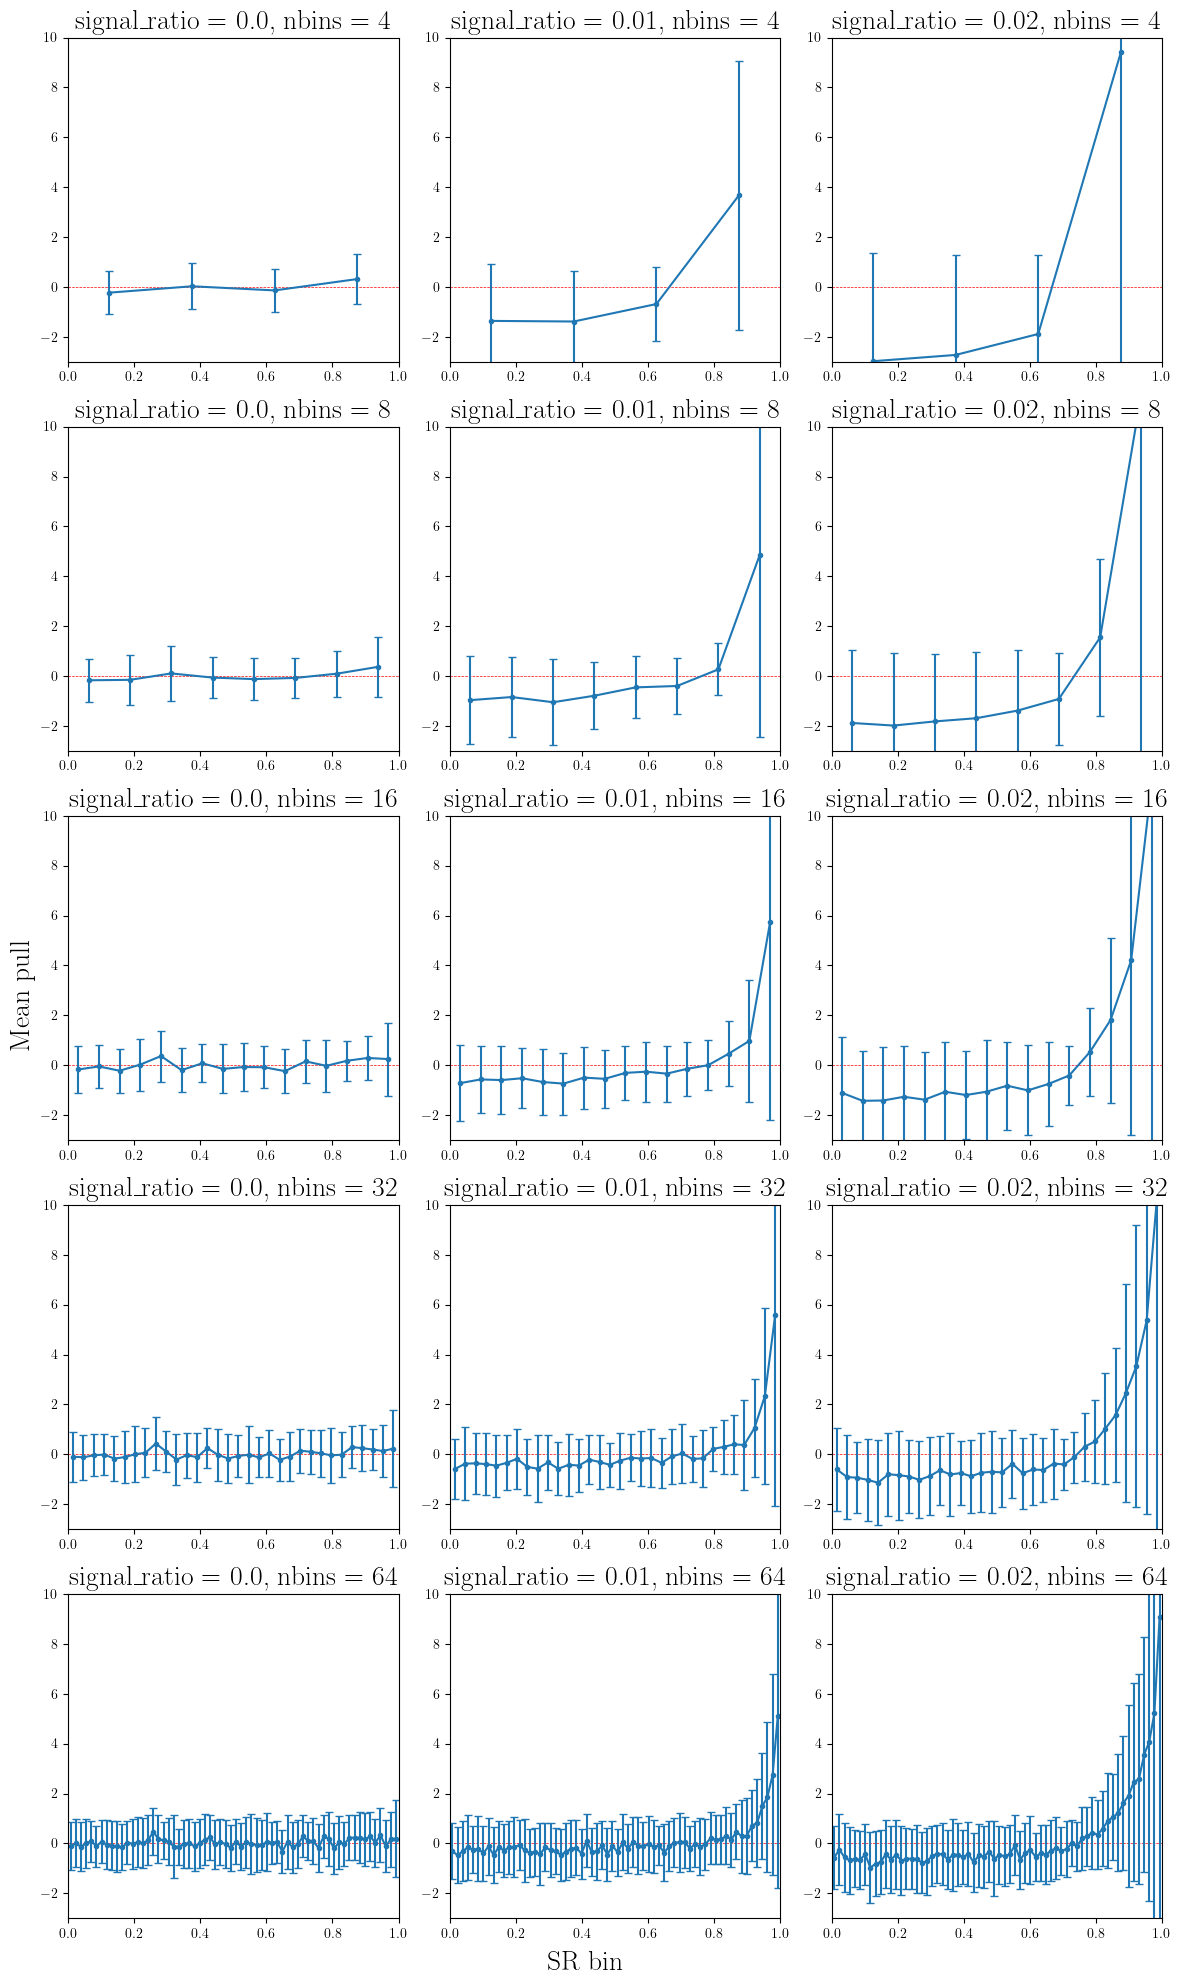

In [7]:
nbins_list = [2**i for i in range(2, 7)]
sig_level = 0.05
z_rej = stats.norm.ppf(1 - sig_level / 2)
    
fig, ax = plt.subplots(len(nbins_list), 3, figsize=(12, 20))
fig.supxlabel("SR bin")
fig.supylabel("Mean pull")
for a in ax.flatten():
    a.set_xlim(0, 1)
    a.set_ylim(-3, 10)
    a.axhline(0, color="red", linestyle="--", linewidth=0.5)
for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    current_ax = ax[i // 3, i % 3]
    current_ax.set_title(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    current_ax.errorbar((np.arange(nbins) + 1 / 2) / nbins, 
                   np.mean(pull_arrays[(signal_ratio, nbins)], axis=0), 
                   yerr=np.std(pull_arrays[(signal_ratio, nbins)], axis=0), 
                   fmt="o-", capsize=3)
    
plt.tight_layout()
plt.show()

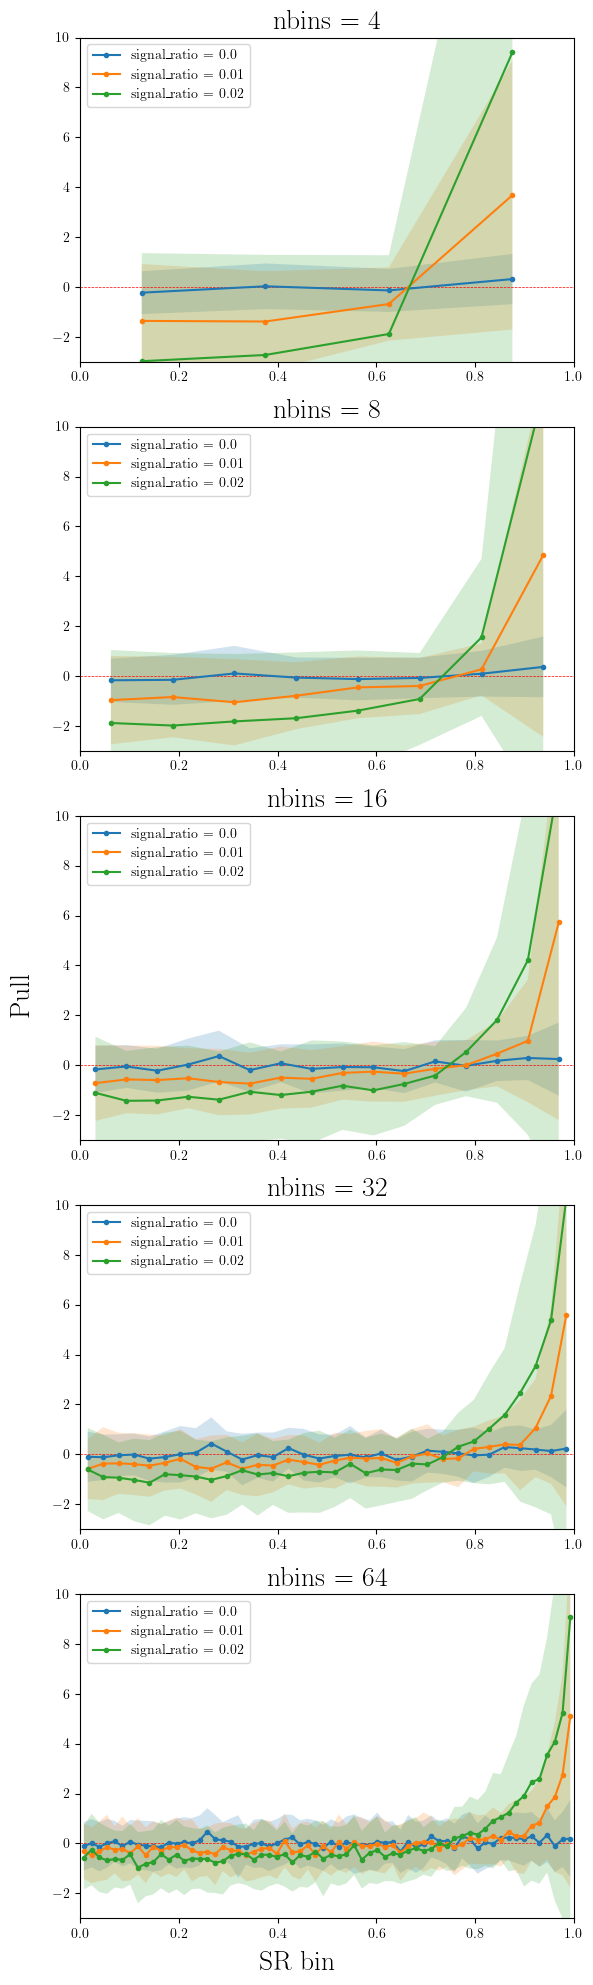

In [9]:
pull_arrays = pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)]
nbins_list = [2**i for i in range(2, 7)]
    
fig, ax = plt.subplots(len(nbins_list), 1, figsize=(6, 20))
fig.supxlabel("SR bin")
fig.supylabel("Pull")
for a in ax.flatten():
    a.set_xlim(0, 1)
    a.set_ylim(-3, 10)
    a.axhline(0, color="red", linestyle="--", linewidth=0.5)
for i, nbins in enumerate(nbins_list):
    current_ax = ax[i]
    current_ax.set_title(f"nbins = {nbins}")
    for signal_ratio in [0.0, 0.01, 0.02]:  
        mean = np.mean(pull_arrays[(signal_ratio, nbins)], axis=0)
        std = np.std(pull_arrays[(signal_ratio, nbins)], axis=0)
        current_ax.plot((np.arange(nbins) + 1 / 2) / nbins, mean, "o-",
                       label=f"signal_ratio = {signal_ratio}")
        current_ax.fill_between((np.arange(nbins) + 1 / 2) / nbins, mean - std, mean + std, alpha=0.2)
    current_ax.legend()
    
plt.tight_layout()
plt.show()

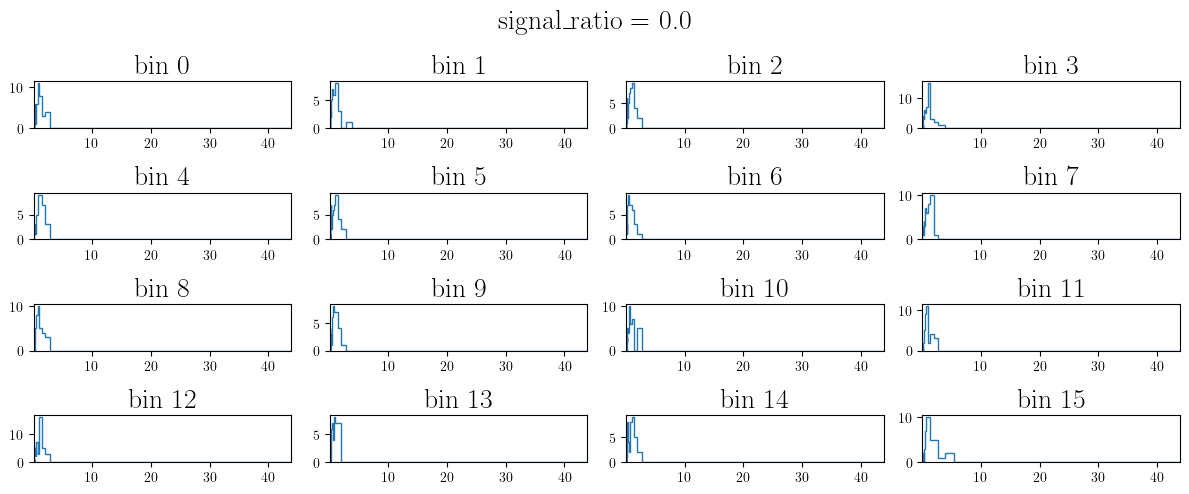

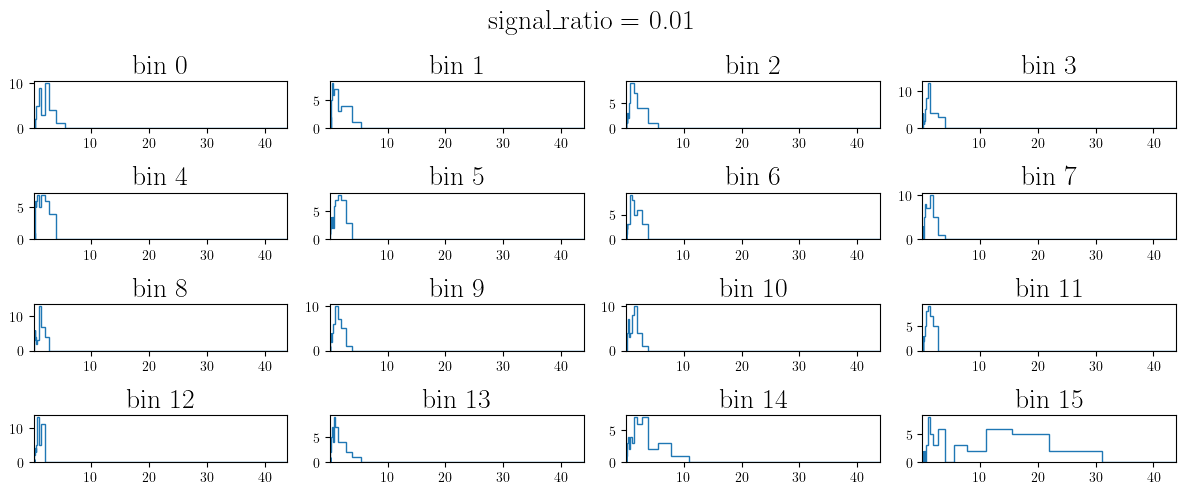

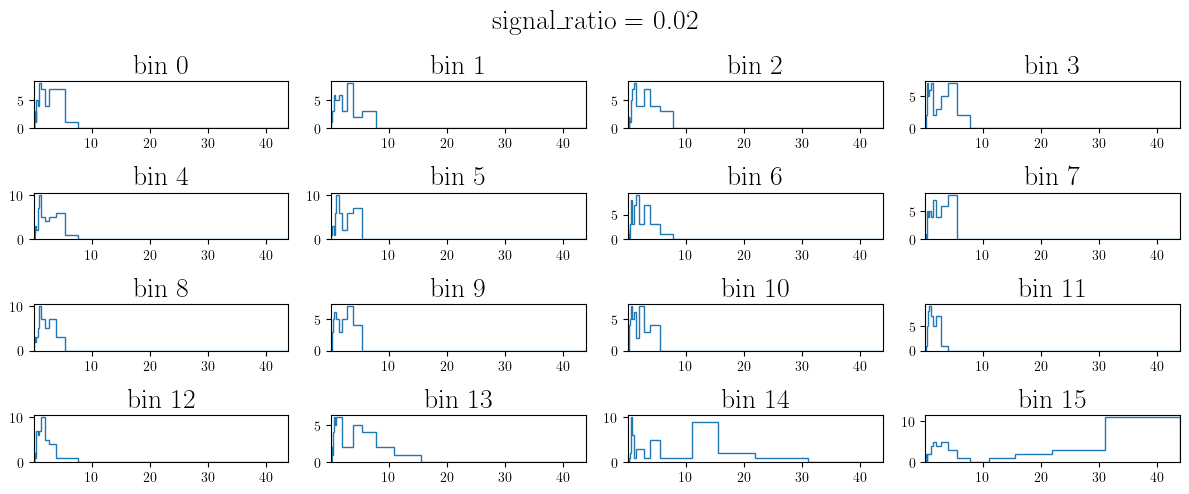

In [9]:
nbins = 16
nrows = 4
ncols = int((nbins + 1) / nrows)
all_pulls = np.abs(np.concatenate([pull_arrays[(signal_ratio, nbins)] for signal_ratio in [0.0, 0.01, 0.02]]))
xmin = np.min(all_pulls)
xmax = np.max(all_pulls)
xrange = (xmin, xmax)
xbins = np.geomspace(*xrange, 30)
for signal_ratio in [0.0, 0.01, 0.02]:
    fig, ax = plt.subplots(nrows, ncols, figsize=(12, 5))
    fig.suptitle(f"signal_ratio = {signal_ratio}")
    for a in ax.flatten():
        a.set_xlim(*xrange)
    for b in range(nbins):
        current_ax = ax[b // ncols, b % ncols]
        current_ax.set_title(f"bin {b}")
        current_ax.hist(np.abs(pull_arrays[(signal_ratio, nbins)][:, b]), histtype="step", bins=xbins)
    plt.tight_layout()
    plt.show()


In [29]:
p_values = {(signal_ratio, nbins): [] for signal_ratio, nbins in pull_arrays.keys()}
for (signal_ratio, nbins), pull_array in pull_arrays.items():
    p_value = stats.chi2.sf(np.sum(pull_array**2, axis=1), df=nbins-1)
    p_values[(signal_ratio, nbins)] = p_value

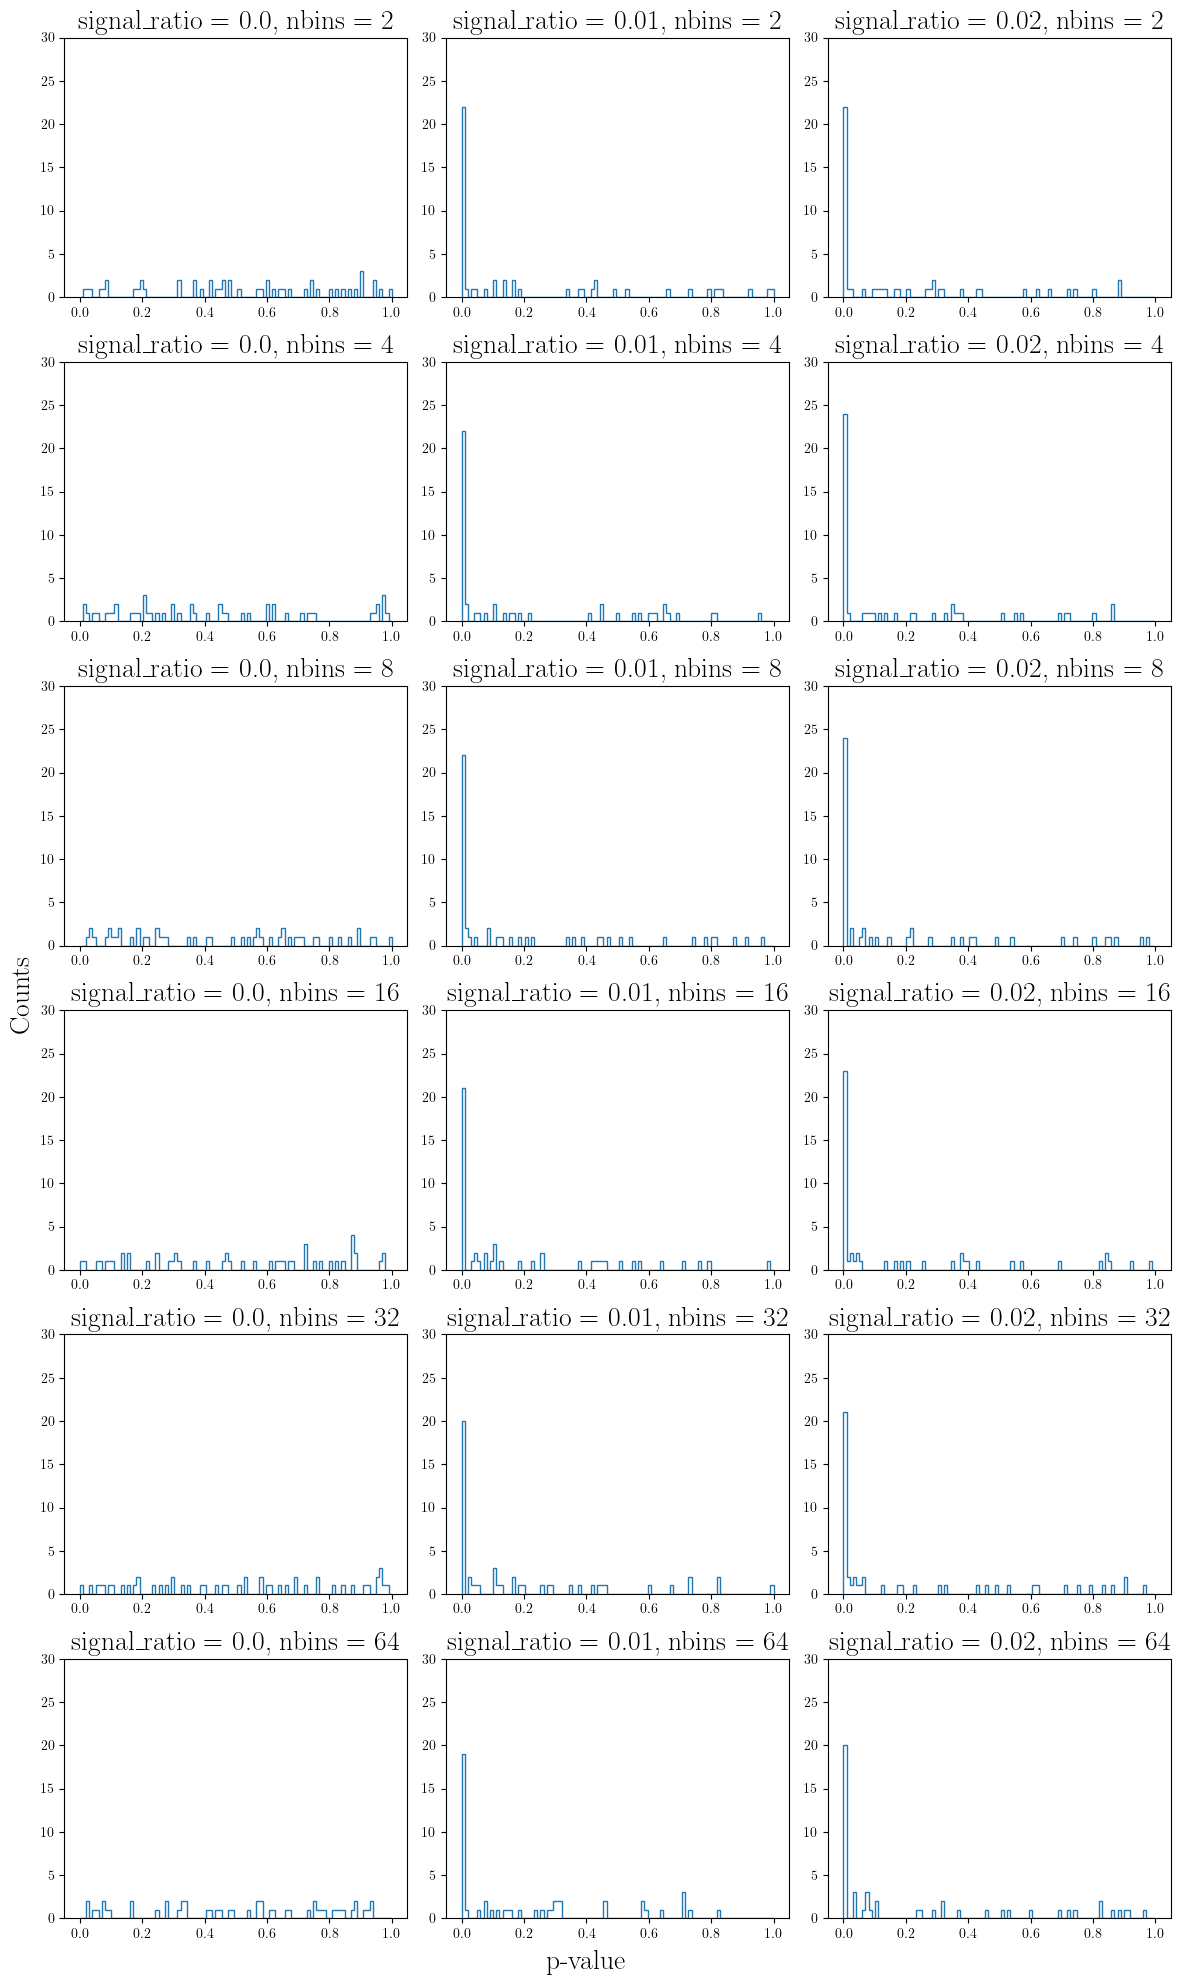

In [34]:
nbins_list = [2**i for i in range(1, 7)]
    
fig, ax = plt.subplots(len(nbins_list), 3, figsize=(12, 20))
fig.supxlabel("p-value")
fig.supylabel("Counts")
for a in ax.flatten():
    a.set_ylim(0, 30)
for i, (nbins, signal_ratio) in enumerate(product(nbins_list, [0.0, 0.01, 0.02])):
    current_ax = ax[i // 3, i % 3]
    current_ax.set_title(f"signal_ratio = {signal_ratio}, nbins = {nbins}")
    current_ax.hist(p_values[(signal_ratio, nbins)], histtype="step", bins=np.linspace(0, 1, 100))
    
plt.tight_layout()
plt.show()